# Regression Analysis

Currently designed to analyze a single file

**Goals**
1. Curve Fit exponential decay
2. Curve Fit oscillations
2. Curve Fit exponential decay and oscillations
3. Fix y-axis scale
4. adjust x-axis scale to new 0 point
5. add error bars?

## Data Preparation

**Import Libraries**

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erf


**Download Files**

In [103]:
col_names = ['Position(mm)', 'Voltage(V)', 'Phase(Theta)'] # Assign custom names

metal = "antimony" # Choose metal (bismuth or antimony)

power = "104.6" # Choose power

df = pd.read_csv(f"{metal}/data/{power}.txt", sep=r"\s+", header=None, names=col_names)

''' Multi-file regression
files = glob.glob(f"{metal}/data/*.txt") # Download files
files = sorted(files) # Sort files '''

' Multi-file regression\nfiles = glob.glob(f"{metal}/data/*.txt") # Download files\nfiles = sorted(files) # Sort files '

**Define Constants**

In [104]:
# speed of light
c = 299792458

# trial length (bismuth: 81, antimony: 161)
trial_len = -1 
if metal == "bismuth":
    trial_len = 81
if metal == "antimony":
    trial_len = 161

**Create Arrays**

In [105]:
position = df["Position(mm)"]
voltage = df["Voltage(V)"] 
time = 2 * (position / 10**3) / c
# Convert voltage from volts to microvolts (10^-6)
voltage = voltage * 10**6

# Convert time from seconds to picoseconds (10^-12)
time = time * 10**12

**Average Trials**

In [106]:
# Separate and average trial runs for each power and each sample

voltage = voltage.groupby(voltage.index % trial_len).mean().reset_index(drop=True)
time = time[ : trial_len]

time_np = time.to_numpy()
voltage_np = voltage.to_numpy()

## Regression Modeling

### Paper Inspired Fit

**Equation of Motion**

$$ \frac{\Delta R}{R} = \frac{1}{2}\left[1+\text{erf}\left(\frac{t-t_{0}}{\tau_{0}}\right)\right]\left[A_{0}e^{-\frac{t-t_{0}}{\tau_{1}}} + A_{1} + A_{\text{osc}}e^{-\frac{t-t_{0}}{\tau_{\text{osc}}}}cos(\omega_{\text{osc}}t + \phi_{\text{osc}}) \right]  $$

**Envelope**

$$ \text{envelope} = \frac{1}{2}\left[1+\text{erf}\left(\frac{t-t_{0}}{\tau_{0}}\right)\right]\left[A_{0}e^{-\frac{t-t_{0}}{\tau_{1}}} + A_{1} \right] $$

In [107]:
def env_model(t, t0, tau0, tau1, A0, A1, B):
    return (1/2) * (1 + erf((t-t0)/tau0)) * (A0 * np.exp(-(t-t0)/tau1) + A1) + B

In [108]:
peak_idx = np.argmin(voltage_np)
t0_guess = time_np[peak_idx]

# pre-pump baseline from points before the dip
pre_mask = time_np < t0_guess - 0.3
baseline = voltage_np[pre_mask].mean()

# data scale
v_range = voltage_np.max() - voltage_np.min()
dip_depth = baseline - voltage_np.min()  # positive number

p0 = [t0_guess, 0.3, 5.0, -dip_depth, 0.1 * v_range, baseline]

bounds = (
    [t0_guess - 0.5,  0.05,  0.1,  -5 * v_range,  -2 * v_range,  baseline - v_range],
    [t0_guess + 0.5,  3.0,   50,    0,             2 * v_range,  baseline + v_range],
)


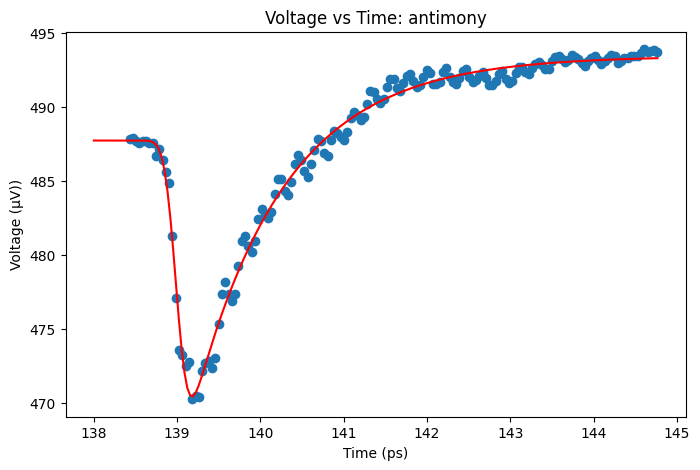

[ 1.39008589e+02  1.57233701e-01  1.09392651e+00 -2.82274912e+01
  5.70747871e+00  4.87722190e+02]


In [109]:
popt, _ = curve_fit(env_model, time_np, voltage_np, p0=p0, bounds=bounds, maxfev=50000)
t0, tau0, tau1, A0, A1, B = popt

t_smooth = np.linspace(138, np.max(time_np), 200)


# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot datai
plt.scatter(time_np, voltage_np)

# Plot model
plt.plot(
    t_smooth,
    env_model(t_smooth, t0, tau0, tau1, A0, A1, B),
    color = "r"
)

plt.xlabel("Time (ps)")
plt.ylabel("Voltage (\u00B5V))")
plt.title(f"Voltage vs Time: {metal}")


plt.show()

print(popt)

$$ \text{signal} = \frac{\Delta R}{R} - \text{envelope} = \frac{1}{2}\left[1+\text{erf}\left(\frac{t-t_{0}}{\tau_{0}}\right)\right]\left[A_{\text{osc}}e^{-\frac{t-t_{0}}{\tau_{\text{osc}}}}cos(\omega_{\text{osc}}t + \phi_{\text{osc}}) \right] $$ 

In [110]:
def osc_model(t, t0, tau0, tauosc, Aosc, w, phi ):
    return (1/2) * (1 + erf((t-t0)/tau0)) * (Aosc * np.exp(-(t-t0)/tauosc) * np.cos(w*t + phi))

In [111]:
osc = voltage_np-env_model(time_np, t0, tau0, tau1, A0, A1, B)

In [139]:
# estimate oscillation params from the residual
osc_amp = np.abs(osc).max()  # ~2 μV from your plot

# antimony A1g phonon: ~4.5 THz → ω = 2π·f ≈ 28 rad/ps
# but let the fitter explore — you can also FFT the residual to get a better guess

p0 = [t0, 0.3, 2.0, osc_amp, 28, 0]
#     t0  tau0 tauosc Aosc  w  phi

bounds = (
    [t0 - 0.5,  0.05,  0.1,   0,         1,    -2*np.pi],
    [t0 + 0.5,  3.0,   50,    5*osc_amp, 100,   2*np.pi],
)

popt, _ = curve_fit(osc_model, time_np, osc, p0=p0, bounds=bounds, maxfev=50000)
t0_o, tau0_o, tauosc, Aosc, w, phi = popt
print(popt)

[139.3144834    0.86449622   1.52014859   2.12820284  28.04903206
  -6.28318531]


τ_osc = 50.00 ps, A = 1.31 μV, f = 4.51 THz, φ = -5.28


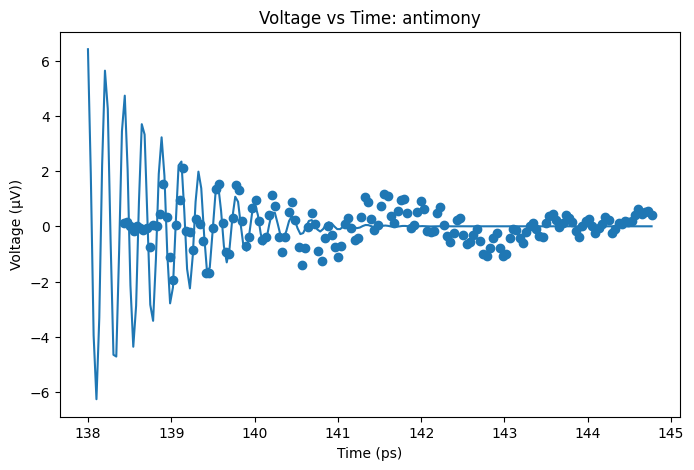

In [144]:
w_guess = 2 * np.pi * 4.5  # ≈ 28.3 rad/ps

def osc_model(t, tauosc, Aosc, w, phi):
    return 0.5 * (1 + erf((t - t0)/tau0)) * Aosc * np.exp(-(t-t0)/tauosc) * np.cos(w*t + phi)

p0 = [2.0, 2.0, w_guess, 0]
bounds = (
    [0.1,  0,   2*np.pi*4.0,  -2*np.pi],
    [50,   10,  2*np.pi*5.0,   2*np.pi],
)

popt, _ = curve_fit(osc_model, time_np, osc, p0=p0, bounds=bounds, maxfev=50000)
print(f"τ_osc = {popt[0]:.2f} ps, A = {popt[1]:.2f} μV, "
      f"f = {popt[2]/(2*np.pi):.2f} THz, φ = {popt[3]:.2f}")

# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time_np, osc)

# Plot model
plt.plot(
    t_smooth,
    osc_model(t_smooth, tauosc, Aosc, w, phi),
)

plt.xlabel("Time (ps)")
plt.ylabel("Voltage (\u00B5V))")
plt.title(f"Voltage vs Time: {metal}")


plt.show()

TypeError: osc_model() takes 5 positional arguments but 7 were given

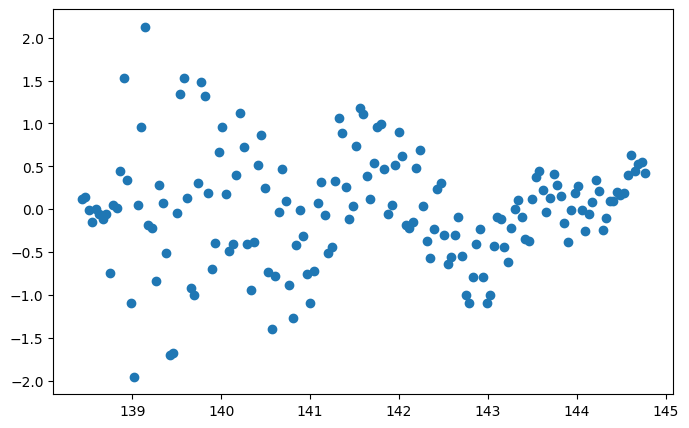

In [143]:
# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time_np, osc)

# Plot model
plt.plot(
    t_smooth,
    osc_model(t_smooth, t0, tau0, tauosc, Aosc, w, phi),
)

plt.xlabel("Time (ps)")
plt.ylabel("Voltage (\u00B5V))")
plt.title(f"Voltage vs Time: {metal}")


plt.show()

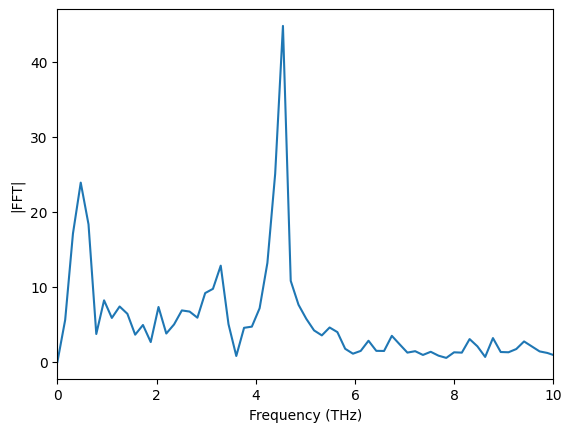

In [141]:
from numpy.fft import rfft, rfftfreq
dt = np.mean(np.diff(time_np))
freqs = rfftfreq(len(osc), dt)
spectrum = np.abs(rfft(osc))
plt.figure()
plt.plot(freqs, spectrum)
plt.xlabel("Frequency (THz)")
plt.ylabel("|FFT|")
plt.xlim(0, 10)
plt.show()